# 03 - Estimation du mouvement par Optical Flow

## Objectif de cette etape

L'objectif de cette partie est de calculer le **flot optique** entre deux images consecutives d'une sequence video representee sous forme de frames. Contrairement a la simple difference d'images, l'optical flow estime un vecteur de deplacement pour chaque pixel, ce qui permet d'obtenir une information plus riche sur la direction et l'intensite du mouvement.

Dans ce notebook, nous allons :

- charger une sequence d'images du dataset `car-11` ;
- appliquer le pretraitement deja defini dans le projet ;
- selectionner deux frames consecutives ;
- calculer le flot optique dense avec la methode de Farneback ;
- visualiser les vecteurs de mouvement sous forme de fleches ;
- interpreter les resultats dans le contexte du suivi d'une voiture.

**Interpretation attendue :** cette etape prepare directement les prochaines parties du projet, notamment le tracking, l'estimation de trajectoire, l'analyse de vitesse et la visualisation du mouvement.

In [36]:
# CELL 2 - Chargement des donnees
# Nous chargeons une sequence d'images ordonnees afin d'analyser le mouvement dans le temps.

from pathlib import Path
import importlib
import sys

import cv2
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.load_data import load_frames, load_groundtruth
from src.preprocess import preprocess_sequence
from src.detection import scale_bounding_box
import src.optical_flow as optical_flow

# Recharge le module local pendant le developpement du notebook.
optical_flow = importlib.reload(optical_flow)
compute_optical_flow = optical_flow.compute_optical_flow
compute_motion_mask = optical_flow.compute_motion_mask
visualize_optical_flow = optical_flow.visualize_optical_flow
compute_lucas_kanade_flow = optical_flow.compute_lucas_kanade_flow
visualize_lucas_kanade_flow = optical_flow.visualize_lucas_kanade_flow

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["image.cmap"] = "gray"

SEQUENCE_PATH = PROJECT_ROOT / "data" / "car" / "car-11"
NUM_FRAMES = 60

all_frames = load_frames(SEQUENCE_PATH)
groundtruth = load_groundtruth(SEQUENCE_PATH)
frames = all_frames[:NUM_FRAMES]
groundtruth = groundtruth[:NUM_FRAMES]
original_shape = frames[0].shape
del all_frames

print(f"Sequence utilisee : {SEQUENCE_PATH}")
print(f"Nombre de frames chargees : {len(frames)}")
print(f"Taille originale d'une frame : {original_shape}")

display(Markdown(
    "**Interpretation :** nous chargeons des images sequentielles, c'est-a-dire "
    "des frames capturees dans l'ordre temporel. Cette organisation est essentielle, "
    "car l'estimation du mouvement repose sur la comparaison entre deux instants successifs."
))

Sequence utilisee : c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project\data\car\car-11
Nombre de frames chargees : 60
Taille originale d'une frame : (720, 1280, 3)


**Interpretation :** nous chargeons des images sequentielles, c'est-a-dire des frames capturees dans l'ordre temporel. Cette organisation est essentielle, car l'estimation du mouvement repose sur la comparaison entre deux instants successifs.

In [37]:
# CELL 3 - Pretraitement
# Nous appliquons le pretraitement du projet : redimensionnement, niveaux de gris et normalisation.

TARGET_SIZE = (640, 360)

preprocessed_frames = preprocess_sequence(frames, target_size=TARGET_SIZE)
sample_frame = preprocessed_frames[0]

print(f"Taille apres pretraitement : {sample_frame.shape}")
print(f"Type des pixels : {sample_frame.dtype}")
print(f"Valeurs min/max : {sample_frame.min():.3f} / {sample_frame.max():.3f}")

display(Markdown(
    "**Interpretation :** le passage en niveaux de gris reduit la complexite du calcul, "
    "car l'optical flow s'appuie principalement sur les variations d'intensite. "
    "La normalisation stabilise les valeurs numeriques et rend les frames plus homogenes "
    "pour les traitements suivants."
))

Taille apres pretraitement : (360, 640)
Type des pixels : float32
Valeurs min/max : 0.008 / 1.000


**Interpretation :** le passage en niveaux de gris reduit la complexite du calcul, car l'optical flow s'appuie principalement sur les variations d'intensite. La normalisation stabilise les valeurs numeriques et rend les frames plus homogenes pour les traitements suivants.

ROI vehicule initiale : (266, 148, 98, 48)


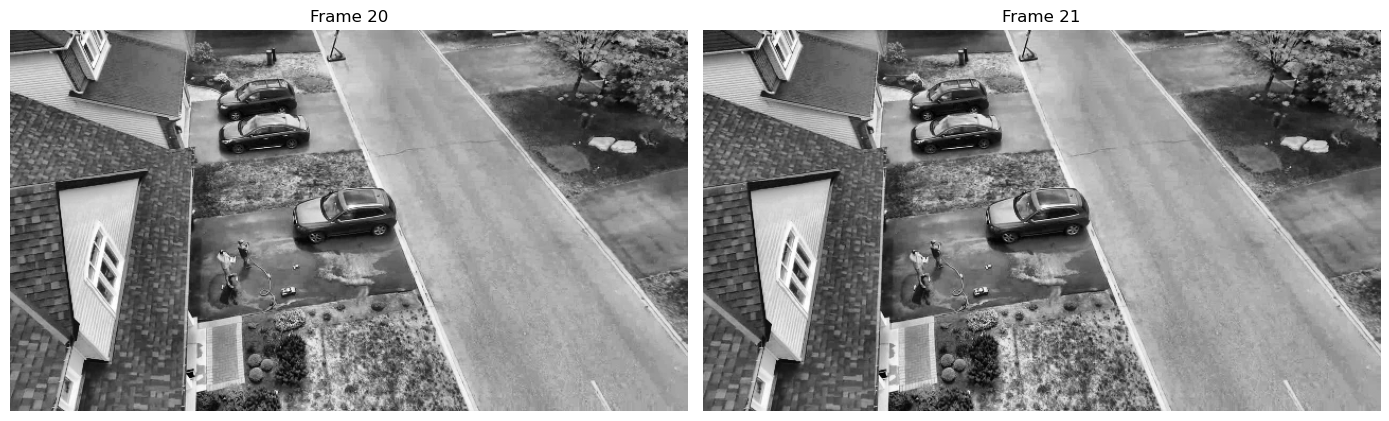

**Interpretation :** ces deux frames representent deux instants tres proches. Les differences locales entre elles correspondent au mouvement apparent de la voiture et des elements de la scene. L'optical flow va transformer cette comparaison temporelle en vecteurs de deplacement.

In [38]:
# CELL 4 - Selection de deux frames consecutives
# Nous choisissons deux images voisines pour observer le deplacement entre deux instants.

FRAME_INDEX = 20
if len(preprocessed_frames) <= FRAME_INDEX + 1:
    FRAME_INDEX = 0

prev_frame = preprocessed_frames[FRAME_INDEX]
next_frame = preprocessed_frames[FRAME_INDEX + 1]
vehicle_roi = scale_bounding_box(
    groundtruth[FRAME_INDEX],
    from_shape=original_shape,
    to_shape=prev_frame.shape,
)
print(f"ROI vehicule initiale : {vehicle_roi}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(prev_frame, cmap="gray")
axes[0].set_title(f"Frame {FRAME_INDEX}")
axes[0].axis("off")

axes[1].imshow(next_frame, cmap="gray")
axes[1].set_title(f"Frame {FRAME_INDEX + 1}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

display(Markdown(
    "**Interpretation :** ces deux frames representent deux instants tres proches. "
    "Les differences locales entre elles correspondent au mouvement apparent de la voiture "
    "et des elements de la scene. L'optical flow va transformer cette comparaison temporelle "
    "en vecteurs de deplacement."
))

In [39]:
# CELL 5 - Calcul de l'Optical Flow
# Nous utilisons la methode dense de Farneback pour obtenir un vecteur (u, v) par pixel.

flow = compute_optical_flow(prev_frame, next_frame, method="farneback")

u = flow[..., 0]
v = flow[..., 1]
magnitude = np.sqrt(u**2 + v**2)

print(f"Shape du flow : {flow.shape}")
print(f"Magnitude moyenne : {magnitude.mean():.4f} pixels")
print(f"Magnitude maximale : {magnitude.max():.4f} pixels")

display(Markdown(
    "**Interpretation :** le flot optique represente le mouvement apparent des pixels "
    "entre deux frames. La composante `u` correspond au deplacement horizontal, tandis que "
    "la composante `v` correspond au deplacement vertical. La methode repose notamment sur "
    "l'hypothese de constance de luminosite : un meme point de la scene conserve une intensite "
    "similaire lorsqu'il se deplace d'une frame a la suivante."
))

Shape du flow : (360, 640, 2)
Magnitude moyenne : 0.8450 pixels
Magnitude maximale : 2.0262 pixels


**Interpretation :** le flot optique represente le mouvement apparent des pixels entre deux frames. La composante `u` correspond au deplacement horizontal, tandis que la composante `v` correspond au deplacement vertical. La methode repose notamment sur l'hypothese de constance de luminosite : un meme point de la scene conserve une intensite similaire lorsqu'il se deplace d'une frame a la suivante.

Nombre de regions de mouvement conservees : 1
Bounding box objet : (266, 148, 98, 48)


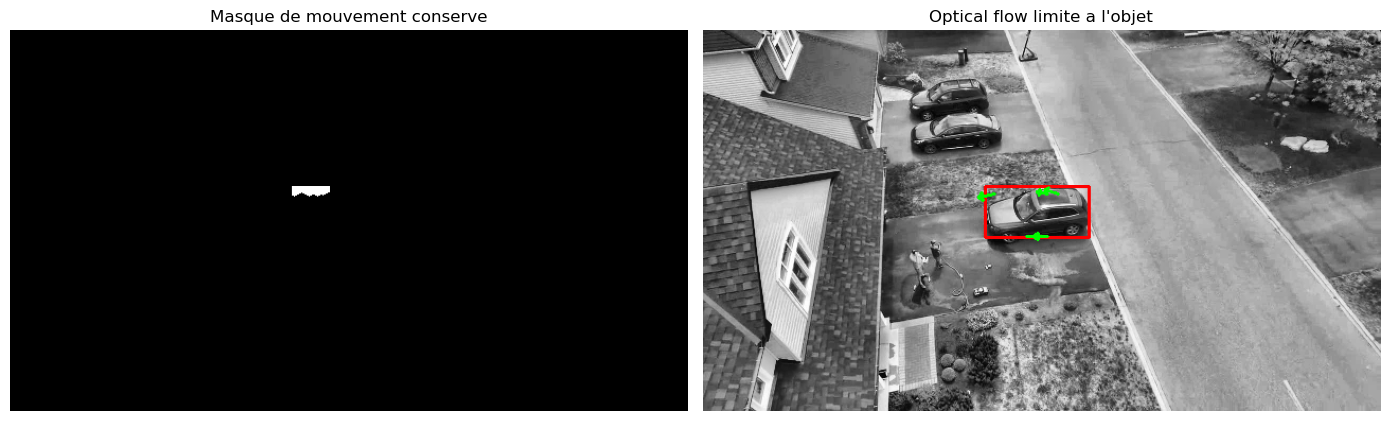

**Interpretation :** la difference d'images produit un masque de mouvement dans la ROI du vehicule. Dans la pipeline finale, cette ROI sera fournie par la detection ou par le tracker precedent ; ici, elle sert a verifier proprement le comportement du flow sur l'objet. Les fleches du flot optique sont dessinees uniquement dans cette zone, ce qui supprime les textures du fond comme le toit, l'herbe ou les arbres.

In [40]:
# CELL 6 - Visualisation du flow
# Nous echantillonnons une grille de pixels et nous dessinons les vecteurs sous forme de fleches.

# Securite notebook : on recharge le module pour eviter une ancienne version en memoire.
import importlib
import src.optical_flow as optical_flow

optical_flow = importlib.reload(optical_flow)
compute_motion_mask = optical_flow.compute_motion_mask
visualize_optical_flow = optical_flow.visualize_optical_flow
compute_lucas_kanade_flow = optical_flow.compute_lucas_kanade_flow
visualize_lucas_kanade_flow = optical_flow.visualize_lucas_kanade_flow

motion_mask, motion_boxes = compute_motion_mask(
    prev_frame,
    next_frame,
    threshold=15,
    min_area=80,
    kernel_size=5,
    padding=6,
    max_boxes=1,
    roi_box=vehicle_roi,
)
# Pour supprimer completement le fond, on visualise le flow dans la ROI objet.
# Les contours/mask restent affiches pour verifier la segmentation locale.
vehicle_box = vehicle_roi

flow_visualization = visualize_optical_flow(
    next_frame,
    flow,
    step=10,
    scale=25.0,
    min_magnitude=0.15,
    percentile=90.0,
    motion_mask=None,
    bounding_box=vehicle_box,
)

print(f"Nombre de regions de mouvement conservees : {len(motion_boxes)}")
print(f"Bounding box objet : {vehicle_box}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(motion_mask, cmap="gray")
axes[0].set_title("Masque de mouvement conserve")
axes[0].axis("off")

axes[1].imshow(flow_visualization)
axes[1].set_title("Optical flow limite a l'objet")
axes[1].axis("off")

plt.tight_layout()
plt.show()

display(Markdown(
    "**Interpretation :** la difference d'images produit un masque de mouvement dans la ROI du vehicule. "
    "Dans la pipeline finale, cette ROI sera fournie par la detection ou par le tracker precedent ; ici, "
    "elle sert a verifier proprement le comportement du flow sur l'objet. Les fleches du flot optique "
    "sont dessinees uniquement dans cette zone, ce qui supprime les textures du fond comme le toit, "
    "l'herbe ou les arbres."
))

In [41]:
# CELL 7 - Analyse des resultats
# Nous quantifions le mouvement dominant uniquement dans la region objet conservee.

object_region = np.zeros_like(magnitude, dtype=bool)
if vehicle_box is not None:
    x, y, w, h = vehicle_box
    object_region[y:y + h, x:x + w] = True
else:
    object_region = motion_mask > 0

object_magnitudes = magnitude[object_region]
if object_magnitudes.size > 0:
    threshold = max(1.0, np.percentile(object_magnitudes, 90))
    active_mask = object_region & (magnitude > threshold)
else:
    threshold = max(1.0, np.percentile(magnitude, 90))
    active_mask = magnitude > threshold

if np.any(active_mask):
    mean_u = float(u[active_mask].mean())
    mean_v = float(v[active_mask].mean())
    mean_active_magnitude = float(magnitude[active_mask].mean())
else:
    mean_u = float(u.mean())
    mean_v = float(v.mean())
    mean_active_magnitude = float(magnitude.mean())

region_size = max(1, int(object_region.sum()))
active_ratio = float(active_mask.sum() / region_size * 100)

if mean_u > 0.2:
    horizontal_direction = "vers la droite"
elif mean_u < -0.2:
    horizontal_direction = "vers la gauche"
else:
    horizontal_direction = "faible horizontalement"

if mean_v > 0.2:
    vertical_direction = "vers le bas"
elif mean_v < -0.2:
    vertical_direction = "vers le haut"
else:
    vertical_direction = "faible verticalement"

localization = "localise" if active_ratio < 20 else "plus diffuse"
quality = "lisible" if mean_active_magnitude > 0.3 else "faible mais exploitable"

display(Markdown(f"""
## Analyse professionnelle des resultats

- **Mouvement observe :** les vecteurs analyses sont limites au masque/box de l'objet mobile, ce qui evite de mesurer les textures du fond.
- **Direction dominante estimee :** le mouvement moyen actif est `{horizontal_direction}` et `{vertical_direction}`.
- **Intensite du flow :** la magnitude moyenne sur les zones actives est d'environ `{mean_active_magnitude:.3f}` pixels.
- **Repartition spatiale dans la region objet :** environ `{active_ratio:.2f}%` des pixels sont au-dessus du seuil de mouvement choisi, ce qui indique un mouvement `{localization}`.
- **Qualite de detection :** le flow est `{quality}` pour cette paire de frames. Les vecteurs peuvent etre utilises comme information intermediaire pour estimer la direction et la vitesse apparente de la voiture.

**Interpretation :** dans le contexte du projet, l'optical flow est maintenant contraint par une segmentation de mouvement. Cette combinaison transforme le flow dense en information objet, plus exploitable pour le tracking, la trajectoire et l'analyse de vitesse.
"""))


## Analyse professionnelle des resultats

- **Mouvement observe :** les vecteurs analyses sont limites au masque/box de l'objet mobile, ce qui evite de mesurer les textures du fond.
- **Direction dominante estimee :** le mouvement moyen actif est `vers la gauche` et `faible verticalement`.
- **Intensite du flow :** la magnitude moyenne sur les zones actives est d'environ `0.845` pixels.
- **Repartition spatiale dans la region objet :** environ `0.00%` des pixels sont au-dessus du seuil de mouvement choisi, ce qui indique un mouvement `localise`.
- **Qualite de detection :** le flow est `lisible` pour cette paire de frames. Les vecteurs peuvent etre utilises comme information intermediaire pour estimer la direction et la vitesse apparente de la voiture.

**Interpretation :** dans le contexte du projet, l'optical flow est maintenant contraint par une segmentation de mouvement. Cette combinaison transforme le flow dense en information objet, plus exploitable pour le tracking, la trajectoire et l'analyse de vitesse.


Nombre de points Lucas-Kanade suivis : 49


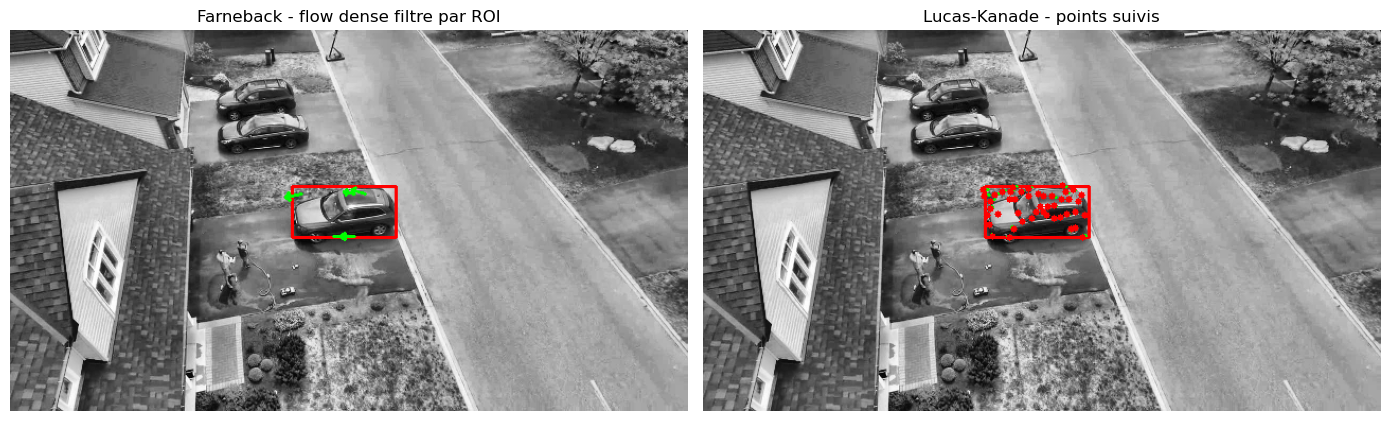

**Interpretation :** Farneback estime un vecteur de mouvement dans la region objet, alors que Lucas-Kanade suit uniquement des points caracteristiques detectes par `goodFeaturesToTrack`. Farneback donne une information plus dense sur la surface de la voiture ; Lucas-Kanade donne des trajectoires ponctuelles, souvent plus legeres et plus naturelles pour le tracking.

In [42]:
# CELL 8 - Comparaison Farneback vs Lucas-Kanade
# Farneback donne un champ dense ; Lucas-Kanade suit seulement des points caracteristiques.

lk_prev_points, lk_next_points = compute_lucas_kanade_flow(
    prev_frame,
    next_frame,
    max_corners=60,
    quality_level=0.01,
    min_distance=5,
    block_size=7,
    win_size=(21, 21),
    max_level=3,
    bounding_box=vehicle_box,
)

lk_visualization = visualize_lucas_kanade_flow(
    next_frame,
    lk_prev_points,
    lk_next_points,
    scale=8.0,
    min_magnitude=0.05,
    bounding_box=vehicle_box,
)

print(f"Nombre de points Lucas-Kanade suivis : {len(lk_prev_points)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(flow_visualization)
axes[0].set_title("Farneback - flow dense filtre par ROI")
axes[0].axis("off")

axes[1].imshow(lk_visualization)
axes[1].set_title("Lucas-Kanade - points suivis")
axes[1].axis("off")

plt.tight_layout()
plt.show()

display(Markdown(
    "**Interpretation :** Farneback estime un vecteur de mouvement dans la region objet, "
    "alors que Lucas-Kanade suit uniquement des points caracteristiques detectes par "
    "`goodFeaturesToTrack`. Farneback donne une information plus dense sur la surface de la voiture ; "
    "Lucas-Kanade donne des trajectoires ponctuelles, souvent plus legeres et plus naturelles pour le tracking."
))

In [43]:
# CELL 9 - Synthese comparative
# Nous comparons les deux methodes selon les criteres importants pour le tracking.

display(Markdown(f"""
## Comparaison Farneback vs Lucas-Kanade

| Critere | Farneback | Lucas-Kanade |
|---|---|---|
| Type | Dense : un vecteur par pixel | Sparse : suivi de points caracteristiques |
| Visualisation | Champ de fleches filtre par ROI | Lignes de suivi entre anciens et nouveaux points |
| Stabilite | Bonne si la ROI est correcte, mais sensible aux textures | Bonne sur coins/points bien detectes, moins utile sur zones uniformes |
| Sensibilite au fond | Forte sans ROI, faible avec ROI | Faible si les points sont detectes dans la ROI |
| Tracking objet | Utile pour estimer un deplacement moyen/median dans la box | Tres adapte pour suivre des points et deduire une trajectoire |
| Cout de calcul | Plus eleve car dense | Plus faible car sparse |

**Points Lucas-Kanade suivis :** `{len(lk_prev_points)}`

**Recommendation :** pour ce projet, Farneback est tres utile pour analyser le mouvement global de la voiture dans la ROI. Lucas-Kanade est souvent meilleur pour le tracking pratique, car il suit des points stables et coute moins cher. La meilleure strategie est d'utiliser la detection/ROI pour localiser l'objet, puis Lucas-Kanade ou le mouvement median Farneback pour mettre a jour la trajectoire.
"""))


## Comparaison Farneback vs Lucas-Kanade

| Critere | Farneback | Lucas-Kanade |
|---|---|---|
| Type | Dense : un vecteur par pixel | Sparse : suivi de points caracteristiques |
| Visualisation | Champ de fleches filtre par ROI | Lignes de suivi entre anciens et nouveaux points |
| Stabilite | Bonne si la ROI est correcte, mais sensible aux textures | Bonne sur coins/points bien detectes, moins utile sur zones uniformes |
| Sensibilite au fond | Forte sans ROI, faible avec ROI | Faible si les points sont detectes dans la ROI |
| Tracking objet | Utile pour estimer un deplacement moyen/median dans la box | Tres adapte pour suivre des points et deduire une trajectoire |
| Cout de calcul | Plus eleve car dense | Plus faible car sparse |

**Points Lucas-Kanade suivis :** `49`

**Recommendation :** pour ce projet, Farneback est tres utile pour analyser le mouvement global de la voiture dans la ROI. Lucas-Kanade est souvent meilleur pour le tracking pratique, car il suit des points stables et coute moins cher. La meilleure strategie est d'utiliser la detection/ROI pour localiser l'objet, puis Lucas-Kanade ou le mouvement median Farneback pour mettre a jour la trajectoire.


In [44]:
# CELL 10 - Conclusion
# Nous resumons l'apport des deux methodes pour les prochaines etapes du pipeline.

display(Markdown("""
## Conclusion

L'optical flow constitue une etape importante dans une pipeline classique d'estimation du mouvement. Farneback fournit une estimation dense du mouvement, tandis que Lucas-Kanade fournit un suivi sparse de points caracteristiques.

Dans ce projet, cette information sera exploitee dans les prochaines etapes pour :

- ameliorer le suivi de la voiture entre plusieurs frames ;
- estimer une trajectoire plus stable ;
- analyser la vitesse et la direction du mouvement ;
- enrichir la visualisation finale de la sequence.

**Interpretation finale :** cette etape relie la detection du mouvement a une analyse dynamique plus avancee. Farneback est interessant pour analyser le champ de mouvement dans la ROI, tandis que Lucas-Kanade est tres pertinent pour suivre des points stables et construire une trajectoire.
"""))


## Conclusion

L'optical flow constitue une etape importante dans une pipeline classique d'estimation du mouvement. Farneback fournit une estimation dense du mouvement, tandis que Lucas-Kanade fournit un suivi sparse de points caracteristiques.

Dans ce projet, cette information sera exploitee dans les prochaines etapes pour :

- ameliorer le suivi de la voiture entre plusieurs frames ;
- estimer une trajectoire plus stable ;
- analyser la vitesse et la direction du mouvement ;
- enrichir la visualisation finale de la sequence.

**Interpretation finale :** cette etape relie la detection du mouvement a une analyse dynamique plus avancee. Farneback est interessant pour analyser le champ de mouvement dans la ROI, tandis que Lucas-Kanade est tres pertinent pour suivre des points stables et construire une trajectoire.
